# Projeto — Análise e Previsão de Evasão Escolar

## Problema

A evasão escolar é um desafio importante para instituições de ensino, pois impacta diretamente o desenvolvimento acadêmico dos estudantes e pode gerar prejuízos sociais e econômicos.

Identificar os fatores que contribuem para o abandono escolar é fundamental para que instituições educacionais possam desenvolver estratégias de prevenção e apoio aos alunos em situação de risco.

Este projeto tem como objetivo analisar dados acadêmicos e socioeconômicos de estudantes para identificar padrões associados à evasão e construir um modelo de machine learning capaz de prever a probabilidade de abandono escolar.

---

## Fonte de Dados

Para este estudo foi utilizado o dataset:

Student Dropout and Academic Success Dataset

Este conjunto de dados contém informações acadêmicas, demográficas e econômicas de estudantes do ensino superior, permitindo analisar os fatores que influenciam a permanência ou evasão no curso.

---

## Principais Variáveis do Dataset

O conjunto de dados inclui variáveis relacionadas a diferentes aspectos da vida acadêmica do estudante:

### Perfil do aluno
- Idade no momento da matrícula
- Gênero
- Estado civil

### Situação financeira
- Situação de pagamento das mensalidades
- Existência de dívidas com a instituição
- Recebimento de bolsa de estudos

### Histórico acadêmico
- Nota de admissão
- Número de disciplinas aprovadas
- Média das notas obtidas
- Frequência acadêmica

### Indicadores econômicos
- Taxa de desemprego
- Taxa de inflação
- Produto Interno Bruto (PIB)

---

## Técnicas Utilizadas no Projeto

Durante o desenvolvimento do projeto foram aplicadas diferentes técnicas de análise de dados e aprendizado de máquina:

### Análise Exploratória de Dados (EDA)

- Distribuição da evasão entre os estudantes
- Análise da evasão por perfil demográfico
- Relação entre desempenho acadêmico e evasão
- Correlação entre variáveis do dataset

### Clusterização (Hierarquia / Aglomerativo)

Foi utilizado o algoritmo de **Clustering Hierárquico Aglomerativo** para identificar grupos de estudantes com características semelhantes, permitindo identificar perfis de alunos com maior risco de evasão.

### Machine Learning

Para prever a situação final do estudante (evasão, matrícula ativa ou conclusão do curso), foi utilizado um modelo de:

- Random Forest Classifier

Esse modelo permite identificar padrões complexos nos dados e avaliar quais variáveis possuem maior influência na previsão da evasão.

---

## Visualizações de Dados

Para facilitar a interpretação dos resultados foram utilizadas diferentes visualizações, como:

- Gráficos de distribuição
- Gráficos de comparação entre grupos
- Heatmap de correlação entre variáveis
- Visualização de clusters
- Gráfico de importância das variáveis no modelo

---

## Ferramentas Utilizadas

As análises foram realizadas utilizando a linguagem Python e as seguintes bibliotecas:

- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn

---

## Metodologia do Projeto

O projeto foi desenvolvido seguindo as principais etapas de um processo de ciência de dados:

1. Coleta e carregamento dos dados  
2. Limpeza e preparação dos dados  
3. Análise exploratória dos dados  
4. Engenharia de atributos (Feature Engineering)  
5. Aplicação de técnicas de clusterização  
6. Construção de modelo de Machine Learning  
7. Avaliação do modelo  
8. Visualização e interpretação dos resultados  
9. Conclusão e insights obtidos

In [166]:
# 1) Impotação das bibliotecas 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [168]:
# 2) Carregamento dos dados 
df = pd.read_csv("data.csv", sep=";")

df.shape

(4424, 37)

In [170]:
# 3) Estrutura dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [172]:
# 4) Estatísticas descritivas 
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [174]:
# 5) Verificação de valores nulos
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

## ANÁLISE EXPLORATÓRIA DE DADOS

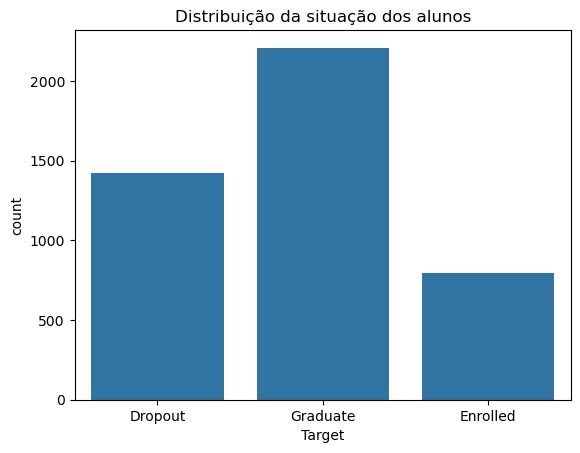

In [176]:
# 6) Distribuição da variável alvo
sns.countplot(x="Target", data=df)

plt.title("Distribuição da situação dos alunos")
plt.show()

# Analisar quantos alunos:
# evadiram
# se formaram
# ainda estão matriculados

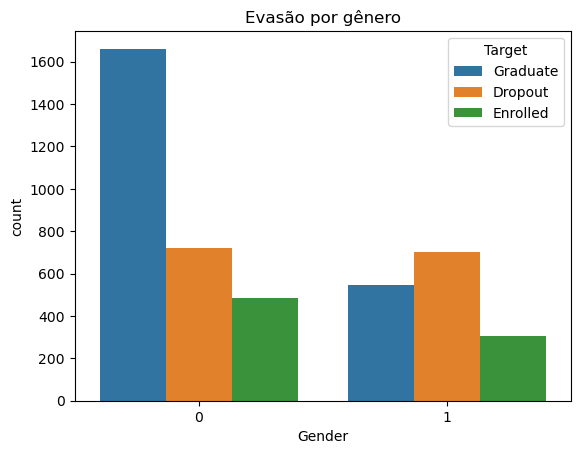

In [178]:
# 7) Evasão pro gênero

sns.countplot(x="Gender", hue="Target",data=df)

plt.title("Evasão por gênero")
plt.show()

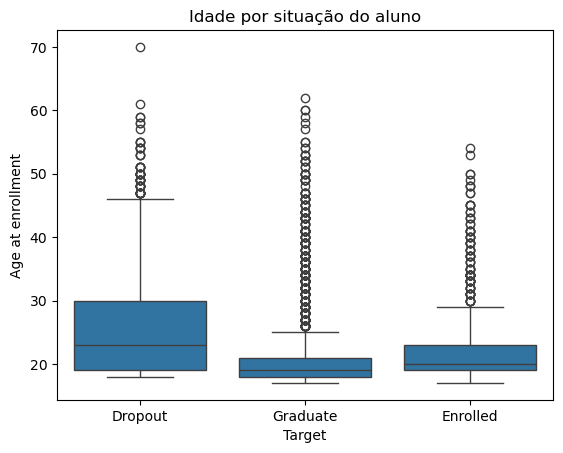

In [180]:
# 8) Evasão po idade

sns.boxplot(x="Target", y="Age at enrollment", data=df)

plt.title("Idade por situação do aluno")
plt.show()

C:\Users\olive\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\olive\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


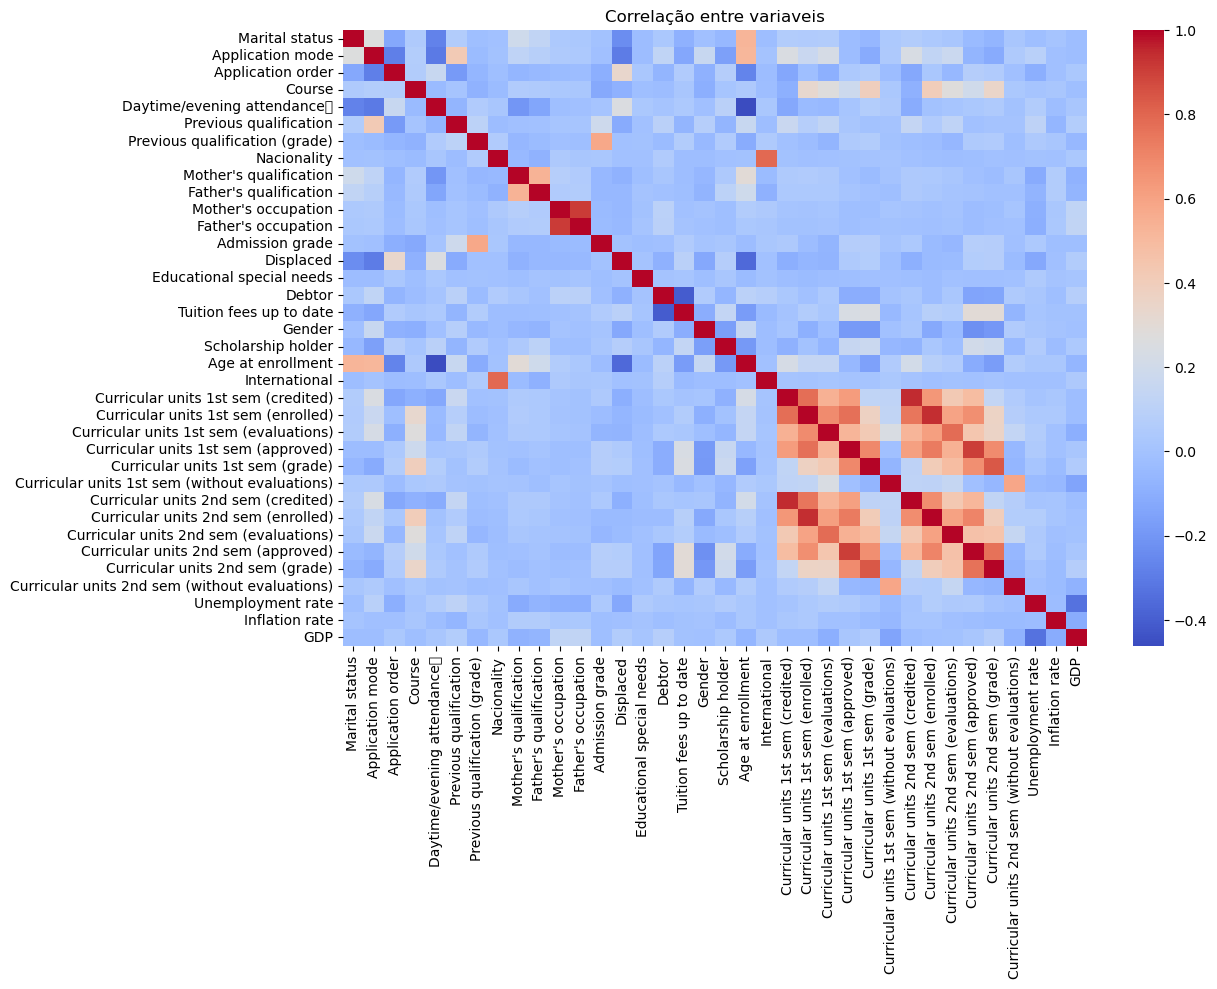

In [182]:
# 9) Correlação entre variáveis

plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap="coolwarm")

plt.title("Correlação entre variaveis")
plt.show()

## Preparação dos dados

In [184]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [186]:
# 10) Transformar variável Target.  Machine learning precisa de valores numéricos.
df["Target"] = df["Target"].replace({
    "Dropout":0,
    "Enrolled":1,
    "Graduate":2
})

C:\Users\olive\AppData\Local\Temp\ipykernel_31672\1554065511.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Target"] = df["Target"].replace({


In [190]:
# 11) Separar variáveis
x = df.drop("Target", axis=1)
y = df["Target"]

## CLUSTERING HIERÁRQUICO (EXIGIDO NO TRABALHO)

In [192]:
# 12) Padronização dos dados

scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [194]:
# 12) Criar modelo aglomerativo
cluster = AgglomerativeClustering(n_clusters=3)
df["cluster"] = cluster.fit_predict(X_scaled)

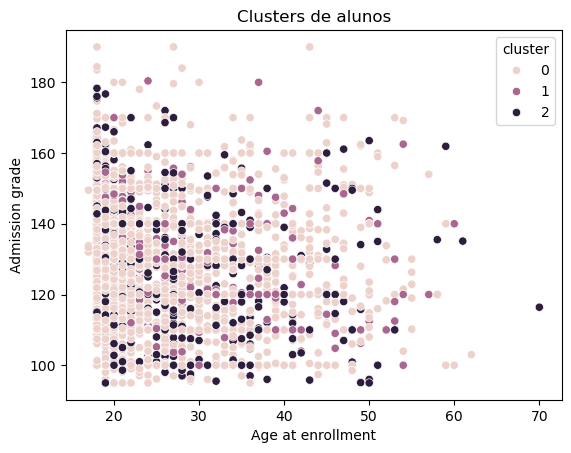

In [196]:
# 13) Visualização dos clusters

sns.scatterplot(
    x=df["Age at enrollment"],
    y=df["Admission grade"],
    hue=df["cluster"]
)

plt.title("Clusters de alunos")
plt.show()

#Isso permite identificar perfis de alunos semelhantes.

## MACHINE LEARNING

In [198]:
# 14) Divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [200]:
# 15) Treinamento do modelo
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [204]:
# 16) Previsões
y_pred = model.predict(X_test)

In [206]:
# 17)Avaliação do modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79       316
           1       0.46      0.27      0.34       151
           2       0.77      0.93      0.84       418

    accuracy                           0.76       885
   macro avg       0.69      0.65      0.66       885
weighted avg       0.74      0.76      0.74       885



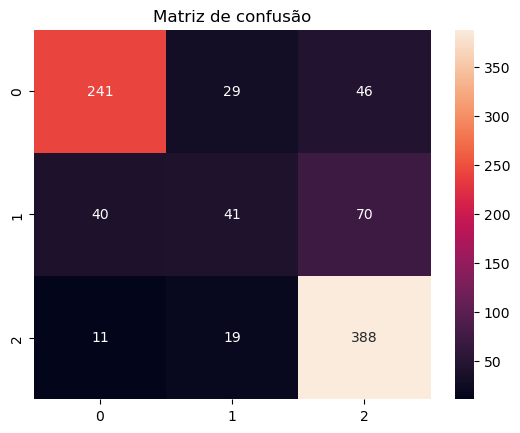

In [208]:
# 17)Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusão")
plt.show()

C:\Users\olive\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


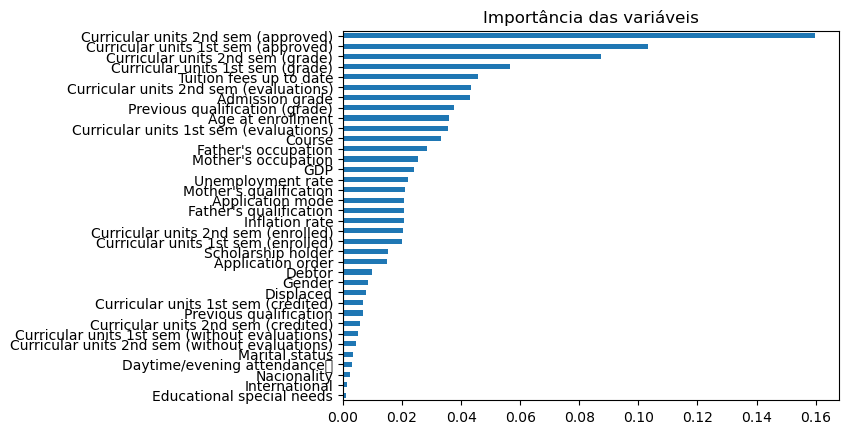

In [220]:
# 18) Importância das variáveis
importances = model.feature_importances_

feat = pd.Series(importances, index=X_train.columns)

feat.sort_values().plot(kind="barh")

plt.title("Importância das variáveis")
plt.show()


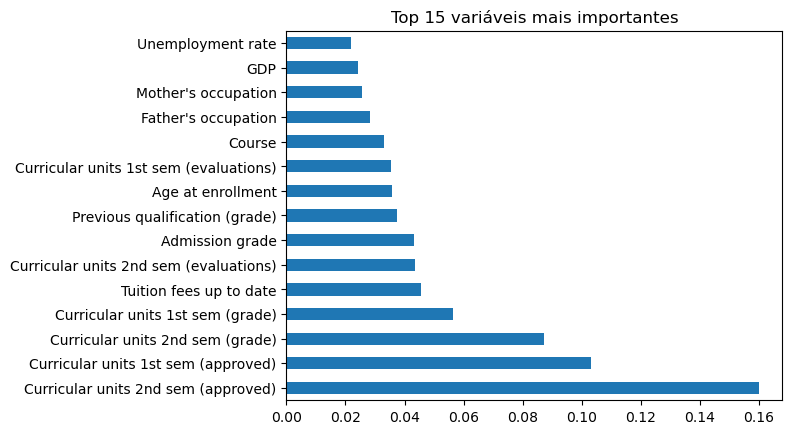

In [222]:
feat.sort_values(ascending=False).head(15).plot(kind="barh")

plt.title("Top 15 variáveis mais importantes")
plt.show()

#Para deixar o gráfico mais limpo:
#Isso mostra as variáveis que mais influenciam a evasão.

# Conclusão do Projeto

## Principais Resultados

A análise dos dados permitiu identificar padrões importantes relacionados ao abandono escolar. Através da análise exploratória foi possível observar que o desempenho acadêmico do estudante é um dos fatores mais relevantes associados à evasão.

Variáveis como número de disciplinas aprovadas, média das notas e frequência acadêmica apresentaram forte relação com a probabilidade de abandono. Estudantes com menor desempenho acadêmico tendem a apresentar maior risco de evasão.

Além disso, fatores financeiros também mostraram impacto relevante. Alunos com dificuldades no pagamento das mensalidades ou sem apoio financeiro apresentaram maior probabilidade de abandonar o curso.

---

## Resultados da Clusterização

A aplicação do método de **Clustering Hierárquico Aglomerativo** permitiu identificar grupos de estudantes com características semelhantes.

Esses agrupamentos revelaram diferentes perfis de alunos, como:

- estudantes com alto desempenho acadêmico e baixo risco de evasão  
- estudantes com desempenho intermediário e risco moderado  
- estudantes com baixo desempenho acadêmico e maior probabilidade de abandono  

Essa segmentação pode ser útil para instituições de ensino desenvolverem estratégias específicas de apoio para cada grupo de alunos.

---

## Resultados do Modelo de Machine Learning

O modelo de **Random Forest** foi utilizado para prever a situação final do estudante com base nas variáveis disponíveis no dataset.

A análise da importância das variáveis mostrou que os principais fatores que influenciam a evasão incluem:

- número de disciplinas aprovadas  
- média das notas obtidas  
- situação de pagamento das mensalidades  
- presença de bolsa de estudos  
- idade do estudante no momento da matrícula  

Essas variáveis demonstram que tanto o desempenho acadêmico quanto fatores socioeconômicos possuem papel importante na permanência do estudante na instituição.

---

## Aplicações Práticas

Os resultados deste projeto podem auxiliar instituições de ensino a:

- identificar estudantes com maior risco de evasão  
- desenvolver programas de acompanhamento acadêmico  
- oferecer suporte financeiro para alunos em situação de vulnerabilidade  
- criar políticas educacionais voltadas para a redução da evasão

A utilização de técnicas de análise de dados e machine learning permite que decisões educacionais sejam tomadas de forma mais estratégica e baseada em evidências.

---

## Trabalhos Futuros

Como possíveis extensões deste projeto, podem ser exploradas as seguintes melhorias:

- utilização de datasets maiores e mais diversificados  
- aplicação de outros algoritmos de machine learning  
- criação de modelos de previsão em tempo real  
- integração com dados educacionais nacionais  

Essas melhorias podem aumentar ainda mais a capacidade de prever e prevenir a evasão escolar.

---

## Considerações Finais

A análise demonstrou que a utilização de técnicas de ciência de dados pode contribuir significativamente para a compreensão do fenômeno da evasão escolar. A combinação de análise exploratória, clusterização e modelos preditivos possibilita identificar padrões relevantes e gerar insights que podem apoiar a tomada de decisão em instituições educacionais.